# EDA croisée — les 5 sources réunies

Les quatre notebooks précédents auditaient **chaque source isolément**. Celui-ci
les croise, ce qui n'était pas possible avant la construction de la base :

| Source | Ce qu'elle apporte |
|---|---|
| BDIFF | 51 401 feux localisés à la commune, 2006-2025 |
| CEMS / Copernicus | les 8 indices feu, chaque jour, chaque maille de 28 km |
| CORINE Land Cover | de quoi chaque commune est faite |
| Référentiel INSEE | population, altitude, relief, distance à la côte |
| INSEE mouvements | les fusions de communes, pour ne perdre aucun feu |

---

### La question qui structure ce notebook

> **Qu'est-ce que le territoire apporte, que la météo ne dit pas ?**

C'est le positionnement du projet. Le FWI est un excellent prédicteur, mais il
est **purement météorologique** : il ne sait rien de la végétation, de la
présence humaine ni de l'historique d'une commune. Si le territoire n'ajoutait
rien, le modèle n'aurait pas de raison d'exister.

### Un principe de lecture : toujours normaliser

Le nombre brut de feux mesure surtout **ce qui est abondant**. Une région
grande a plus de feux qu'une petite ; l'agricole couvre 60 % de la France,
donc il totalise beaucoup de feux. La question utile est toujours
**« combien par unité de surface disponible ? »** — et le classement change
souvent du tout au tout.

## 1. Chargement

Les agrégats viennent de la base (`sql/eda/agg*.sql`), déjà calculés : certains
balaient les 253 M lignes de la grille, ce serait trop lent à refaire ici.

In [ ]:
# ── enregistrement automatique des figures ──
# chaque plt.show() écrit aussi un PNG dans figures/data-all/
import sys
from pathlib import Path

for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "src" / "tvfed").is_dir():
        sys.path.insert(0, str(_p / "src"))
        break

from tvfed.figures import activer

activer("data-all")

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap

# le paquet vit dans src/ — on l'ajoute au path depuis notebook/
for p in (Path.cwd(), *Path.cwd().parents):
    if (p / "src" / "tvfed").is_dir():
        sys.path.insert(0, str(p / "src"))
        break
from tvfed import db  # noqa: E402

# ── charte graphique, identique aux 4 notebooks d'audit ──
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
BLEU, ORANGE, ROUGE, VERT, VIOLET = "#2a78d6", "#eb6834", "#e34948", "#1baf7a", "#4a3aa7"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.size": 9, "axes.edgecolor": "#c3c2b7", "text.color": INK})
MOIS = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]
DEB_MOIS = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
ASPECT = 1 / np.cos(np.deg2rad(46))

# couleurs officielles EFFIS — la carte sera reconnaissable au premier coup d'œil
COUL_EFFIS = ["#84F07F", "#FFEB3C", "#FFB00C", "#FA4F00", "#B40000", "#280923"]
NOM_EFFIS = ["Très faible", "Faible", "Moyen", "Élevé", "Très élevé", "Extrême"]

# une couleur par type de végétation, réutilisée partout
COUL_VEG = {
    "maquis / garrigue": "#e34948", "conifères": "#0f6e56", "feuillus": "#1baf7a",
    "agricole": "#eda100", "urbain": "#898781", "mixte": "#86b6ef",
}
ORDRE_VEG = ["maquis / garrigue", "conifères", "mixte", "feuillus", "urbain", "agricole"]

REGIONS = {
    "11": "Île-de-France", "24": "Centre-Val de Loire", "27": "Bourgogne-Franche-Comté",
    "28": "Normandie", "32": "Hauts-de-France", "44": "Grand Est", "52": "Pays de la Loire",
    "53": "Bretagne", "75": "Nouvelle-Aquitaine", "76": "Occitanie",
    "84": "Auvergne-Rhône-Alpes", "93": "PACA", "94": "Corse",
}


def lire(table):
    with db.connexion() as conn:
        return pd.read_sql(f"SELECT * FROM {table}", conn)


COM = lire("eda_commune")
EFFIS = lire("eda_effis").sort_values("classe_effis")
VEG_FWI = lire("eda_fwi_vegetation")
VEG_EXPO = lire("eda_expo_vegetation")
VEG_EFFIS = lire("eda_veg_effis")
ALT = lire("eda_altitude").sort_values("bande")
SAISON = lire("eda_saison_veg")

COM["reg_nom"] = COM.reg_code.map(REGIONS)
JOURS = 7305  # 2006-2025

print(f"communes           {len(COM):,}   dont {(COM.nb_feux > 0).sum():,} touchées")
print(f"feux               {COM.nb_feux.sum():,}")
print(f"hectares brûlés    {COM.ha_brules.sum():,.0f}")
print(f"période            2006-2025 ({JOURS:,} jours)")

C:\Users\romua\AppData\Local\Temp\ipykernel_1364\3663205354.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(f"SELECT * FROM {table}", conn)
C:\Users\romua\AppData\Local\Temp\ipykernel_1364\3663205354.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(f"SELECT * FROM {table}", conn)
C:\Users\romua\AppData\Local\Temp\ipykernel_1364\3663205354.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(f"SELECT * FROM {table}", conn)


communes           34,734   dont 9,437 touchées
feux               51,401
hectares brûlés    237,969
période            2006-2025 (7,305 jours)


## 2. Où sont les feux, où sont les gens, où est le combustible

Trois cartes à la même échelle. La première question de l'analyse spatiale est
de savoir **laquelle des deux autres** explique la première.

Puis un test de l'hypothèse classique : *9 feux sur 10 sont d'origine humaine*.
Si c'est vrai, on devrait voir plus de feux là où il y a des gens — mais les
zones habitées ont aussi **moins de végétation**. Les deux effets pourraient
se compenser.

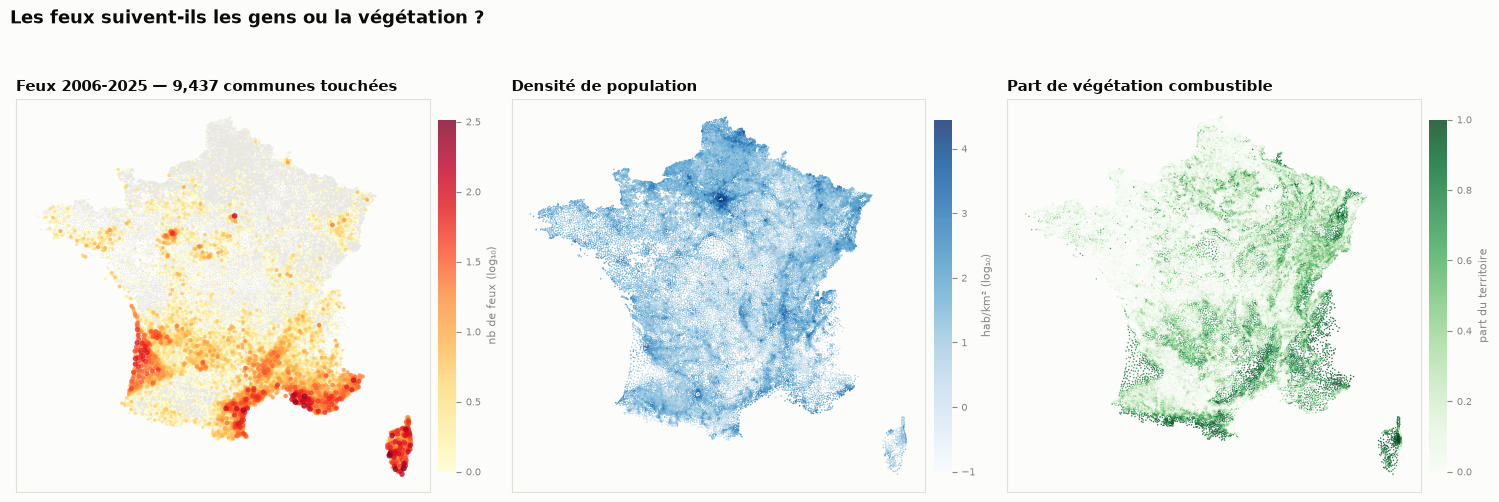

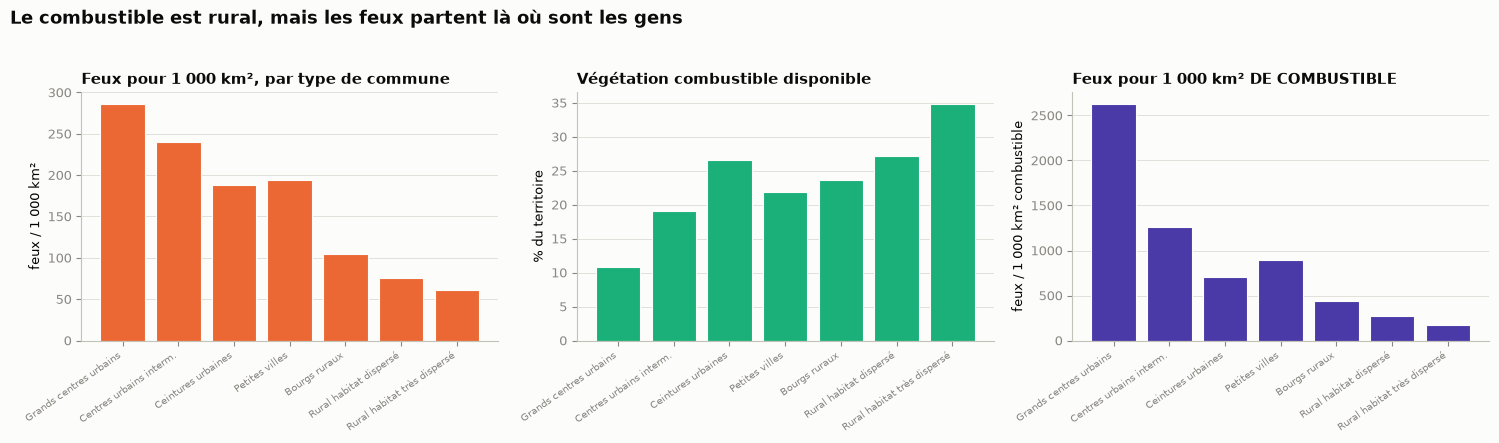

À surface de combustible ÉGALE, les grands centres urbains brûlent 15× plus
que le rural à habitat très dispersé — alors qu'ils ont 3× moins de végétation.

⚠️  Une relation en cloche était attendue (peu d'habitants = pas d'allumage,
    beaucoup d'habitants = pas de végétation). Les données la réfutent :
    la relation est monotone. L'allumage humain domine largement.
⚠️  Confusion possible à vérifier : PACA et la Corse cumulent forte
    urbanisation littorale ET climat méditerranéen. Le croisement
    végétation × classe EFFIS ci-dessous permet de trancher.


In [2]:
"""FIG 1 — Où sont les feux, et où sont les gens."""
fig, ax = plt.subplots(1, 3, figsize=(15, 5.2))

# (a) les feux en absolu
touche = COM[COM.nb_feux > 0].sort_values("nb_feux")
ax[0].scatter(COM.lon, COM.lat, s=.8, c="#e8e7e0", edgecolors="none")
s = ax[0].scatter(touche.lon, touche.lat, s=1 + 3 * np.log1p(touche.nb_feux),
                  c=np.log10(touche.nb_feux), cmap="YlOrRd", alpha=.8, edgecolors="none")
ax[0].set_title(f"Feux 2006-2025 — {(COM.nb_feux>0).sum():,} communes touchées",
                fontsize=11, weight="bold", loc="left")
cb = fig.colorbar(s, ax=ax[0], fraction=.04, pad=.02)
cb.set_label("nb de feux (log₁₀)", fontsize=8, color=MUTED)

# (b) la densité de population, même échelle géographique
s = ax[1].scatter(COM.lon, COM.lat, s=1.2, c=np.log10(COM.densite.clip(lower=.1)),
                  cmap="Blues", alpha=.8, edgecolors="none")
ax[1].set_title("Densité de population", fontsize=11, weight="bold", loc="left")
cb = fig.colorbar(s, ax=ax[1], fraction=.04, pad=.02)
cb.set_label("hab/km² (log₁₀)", fontsize=8, color=MUTED)

# (c) le maquis, pour comparer
s = ax[2].scatter(COM.lon, COM.lat, s=1.2, c=COM.part_combustible.fillna(0),
                  cmap="Greens", alpha=.8, edgecolors="none", vmin=0, vmax=1)
ax[2].set_title("Part de végétation combustible", fontsize=11, weight="bold", loc="left")
cb = fig.colorbar(s, ax=ax[2], fraction=.04, pad=.02)
cb.set_label("part du territoire", fontsize=8, color=MUTED)

for a in ax:
    a.set_aspect(ASPECT); a.set_xticks([]); a.set_yticks([])
    for sp in a.spines.values():
        sp.set_color("#e1e0d9")
for cb_ax in fig.axes[3:]:
    cb_ax.tick_params(labelsize=7, colors=MUTED)
    cb_ax.spines[:].set_visible(False)
fig.suptitle("Les feux suivent-ils les gens ou la végétation ?",
             fontsize=13, weight="bold", x=.005, ha="left", y=1.02)
plt.tight_layout(); plt.show()

# ── FIG 2 : la courbe en cloche de l'origine humaine ──
# 9 feux sur 10 sont d'origine humaine. Mais trop d'habitants = plus de
# végétation. On s'attend donc à un optimum, pas à une relation monotone.
GRILLE_DENS = {1: "Grands centres urbains", 2: "Centres urbains interm.",
               3: "Ceintures urbaines", 4: "Petites villes",
               5: "Bourgs ruraux", 6: "Rural habitat dispersé",
               7: "Rural habitat très dispersé"}
g = (COM.dropna(subset=["grille_densite"])
       .groupby("grille_densite")
       .agg(communes=("code_insee", "size"), feux=("nb_feux", "sum"),
            ha=("ha_brules", "sum"), km2=("superficie_km2", "sum"),
            comb=("part_combustible", "mean")))
g["feux_par_1000km2"] = 1000 * g.feux / g.km2
g["libelle"] = [GRILLE_DENS.get(int(i), str(i)) for i in g.index]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].bar(range(len(g)), g.feux_par_1000km2, color=ORANGE, edgecolor="#fcfcfb", linewidth=.8)
ax[0].set_xticks(range(len(g)))
ax[0].set_xticklabels(g.libelle, rotation=35, ha="right", fontsize=7.5)
ax[0].set_title("Feux pour 1 000 km², par type de commune", fontsize=10.5,
                weight="bold", loc="left")
ax[0].set_ylabel("feux / 1 000 km²")

ax[1].bar(range(len(g)), 100 * g.comb, color=VERT, edgecolor="#fcfcfb", linewidth=.8)
ax[1].set_xticks(range(len(g)))
ax[1].set_xticklabels(g.libelle, rotation=35, ha="right", fontsize=7.5)
ax[1].set_title("Végétation combustible disponible", fontsize=10.5, weight="bold", loc="left")
ax[1].set_ylabel("% du territoire")

# le taux de feu RAPPORTÉ au combustible disponible : c'est ça, l'effet humain pur
g["feux_par_km2_combustible"] = g.feux / (g.km2 * g.comb) * 1000
ax[2].bar(range(len(g)), g.feux_par_km2_combustible, color=VIOLET,
          edgecolor="#fcfcfb", linewidth=.8)
ax[2].set_xticks(range(len(g)))
ax[2].set_xticklabels(g.libelle, rotation=35, ha="right", fontsize=7.5)
ax[2].set_title("Feux pour 1 000 km² DE COMBUSTIBLE", fontsize=10.5, weight="bold", loc="left")
ax[2].set_ylabel("feux / 1 000 km² combustible")

for a in ax:
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
fig.suptitle("Le combustible est rural, mais les feux partent là où sont les gens",
             fontsize=13, weight="bold", x=.005, ha="left", y=1.04)
plt.tight_layout(); plt.show()

r = g.feux_par_km2_combustible.max() / g.feux_par_km2_combustible.min()
print(f"À surface de combustible ÉGALE, les grands centres urbains brûlent {r:.0f}× plus")
print("que le rural à habitat très dispersé — alors qu'ils ont 3× moins de végétation.")
print()
print("⚠️  Une relation en cloche était attendue (peu d'habitants = pas d'allumage,")
print("    beaucoup d'habitants = pas de végétation). Les données la réfutent :")
print("    la relation est monotone. L'allumage humain domine largement.")
print("⚠️  Confusion possible à vérifier : PACA et la Corse cumulent forte")
print("    urbanisation littorale ET climat méditerranéen. Le croisement")
print("    végétation × classe EFFIS ci-dessous permet de trancher.")

## 3. La végétation

Quatre vues de la même donnée. Les deux premières mesurent l'abondance, la
troisième mesure le risque réel. **C'est la normalisation qui renverse le
classement.**

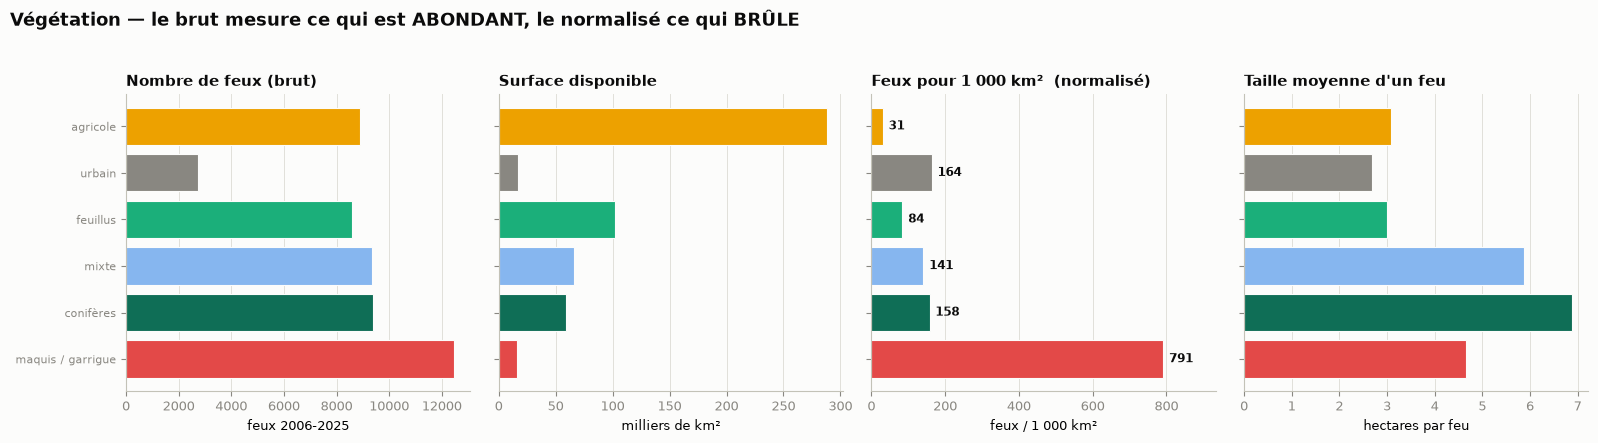

En brut, l'agricole (8,895 feux) rivalise avec le maquis (12,464).
Normalisé, le maquis brûle 26× plus par km².


In [3]:
"""FIG 3 — La végétation : brut vs normalisé, deux histoires opposées."""
V = (VEG_FWI.groupby("vegetation")
     .agg(feux=("fwi", "size"), ha=("ha", "sum"), fwi_moy=("fwi", "mean"))
     .join(VEG_EXPO.set_index("vegetation")))
V["feux_par_1000km2"] = 1000 * V.feux / V.km2
V["ha_par_feu"] = V.ha / V.feux
V = V.reindex([v for v in ORDRE_VEG if v in V.index])
COUL = [COUL_VEG[v] for v in V.index]

fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))

ax[0].barh(V.index, V.feux, color=COUL, edgecolor="#fcfcfb", linewidth=.8)
ax[0].set_title("Nombre de feux (brut)", fontsize=10.5, weight="bold", loc="left")
ax[0].set_xlabel("feux 2006-2025")

ax[1].barh(V.index, V.km2 / 1000, color=COUL, edgecolor="#fcfcfb", linewidth=.8)
ax[1].set_title("Surface disponible", fontsize=10.5, weight="bold", loc="left")
ax[1].set_xlabel("milliers de km²")

ax[2].barh(V.index, V.feux_par_1000km2, color=COUL, edgecolor="#fcfcfb", linewidth=.8)
for i, v in enumerate(V.feux_par_1000km2):
    ax[2].text(v + V.feux_par_1000km2.max() * .02, i, f"{v:.0f}", va="center",
               fontsize=8.5, weight="bold")
ax[2].set_title("Feux pour 1 000 km²  (normalisé)", fontsize=10.5, weight="bold", loc="left")
ax[2].set_xlabel("feux / 1 000 km²")
ax[2].set_xlim(0, V.feux_par_1000km2.max() * 1.18)

ax[3].barh(V.index, V.ha_par_feu, color=COUL, edgecolor="#fcfcfb", linewidth=.8)
ax[3].set_title("Taille moyenne d'un feu", fontsize=10.5, weight="bold", loc="left")
ax[3].set_xlabel("hectares par feu")

for a in ax:
    a.grid(axis="x", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
    a.tick_params(axis="y", labelsize=8)
for a in ax[1:]:
    a.set_yticklabels([])
fig.suptitle("Végétation — le brut mesure ce qui est ABONDANT, le normalisé ce qui BRÛLE",
             fontsize=13, weight="bold", x=.005, ha="left", y=1.04)
plt.tight_layout(); plt.show()

print(f"En brut, l'agricole ({V.loc['agricole','feux']:,.0f} feux) rivalise avec le "
      f"maquis ({V.loc['maquis / garrigue','feux']:,.0f}).")
print(f"Normalisé, le maquis brûle {V.loc['maquis / garrigue','feux_par_1000km2'] / V.loc['agricole','feux_par_1000km2']:.0f}× plus par km².")

## 4. Le croisement central : à météo ÉGALE

Le graphique précédent souffre d'un biais : le maquis est méditerranéen, donc
il subit un FWI structurellement élevé. Comparer le « FWI moyen au moment du
feu » entre végétations mesure surtout la **géographie**, pas la végétation.

La bonne question est donc :

> **À classe de danger EFFIS identique, quelle végétation brûle le plus ?**

Si l'écart persiste à météo constante, alors la végétation porte une
information que le FWI, par construction, ne peut pas contenir.

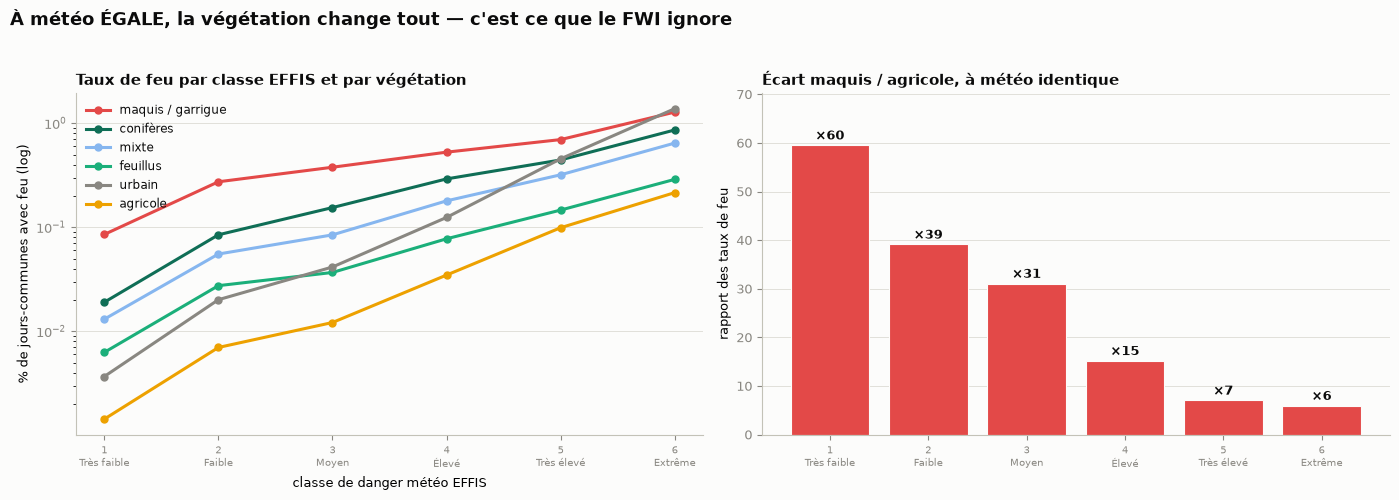

Le FWI est purement météorologique : il ne sait rien de la végétation.
Or à classe EFFIS identique, le maquis brûle de ×6 à ×60
plus que l'agricole. C'est exactement l'information que le modèle ajoute.


In [4]:
"""FIG 4 — le croisement central : à météo ÉGALE, quelle végétation brûle ?"""
# ════════════════════════════════════════════════════════════════
# FIG 4 — LE croisement central : à météo ÉGALE, quelle végétation brûle ?
# ════════════════════════════════════════════════════════════════
piv = VEG_EFFIS.pivot_table(index="vegetation", columns="classe_effis",
                            values=["feux", "jours_communes"], aggfunc="sum")
taux = (100 * piv["feux"] / piv["jours_communes"]).reindex(
    [v for v in ORDRE_VEG if v in piv.index])

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

for v in taux.index:
    ax[0].plot(taux.columns, taux.loc[v], marker="o", ms=5, lw=2.2,
               color=COUL_VEG[v], label=v)
ax[0].set_yscale("log")
ax[0].set_xticks(range(1, 7))
ax[0].set_xticklabels([f"{i}\n{n}" for i, n in zip(range(1, 7), NOM_EFFIS)], fontsize=7.5)
ax[0].set_title("Taux de feu par classe EFFIS et par végétation",
                fontsize=11, weight="bold", loc="left")
ax[0].set_ylabel("% de jours-communes avec feu (log)")
ax[0].set_xlabel("classe de danger météo EFFIS")
ax[0].legend(frameon=False, fontsize=8.5, loc="upper left")

# l'écart maquis / agricole à chaque niveau de danger : ce que la météo
# ne peut PAS expliquer
ratio = taux.loc["maquis / garrigue"] / taux.loc["agricole"]
ax[1].bar(ratio.index, ratio.values, color=ROUGE, edgecolor="#fcfcfb", linewidth=.8)
for i, v in zip(ratio.index, ratio.values):
    ax[1].text(i, v + ratio.max() * .02, f"×{v:.0f}", ha="center", fontsize=9, weight="bold")
ax[1].set_xticks(range(1, 7))
ax[1].set_xticklabels([f"{i}\n{n}" for i, n in zip(range(1, 7), NOM_EFFIS)], fontsize=7.5)
ax[1].set_title("Écart maquis / agricole, à météo identique",
                fontsize=11, weight="bold", loc="left")
ax[1].set_ylabel("rapport des taux de feu")
ax[1].set_ylim(0, ratio.max() * 1.18)

for a in ax:
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
fig.suptitle("À météo ÉGALE, la végétation change tout — c'est ce que le FWI ignore",
             fontsize=13, weight="bold", x=.005, ha="left", y=1.03)
plt.tight_layout(); plt.show()

print("Le FWI est purement météorologique : il ne sait rien de la végétation.")
print(f"Or à classe EFFIS identique, le maquis brûle de ×{ratio.min():.0f} à ×{ratio.max():.0f}")
print("plus que l'agricole. C'est exactement l'information que le modèle ajoute.")

## 5. Altitude

Même piège que pour la végétation : le nombre brut de feux suit la
**démographie** — il y a énormément de communes en plaine. Rapporté à la
surface, un étage à risque apparaît.

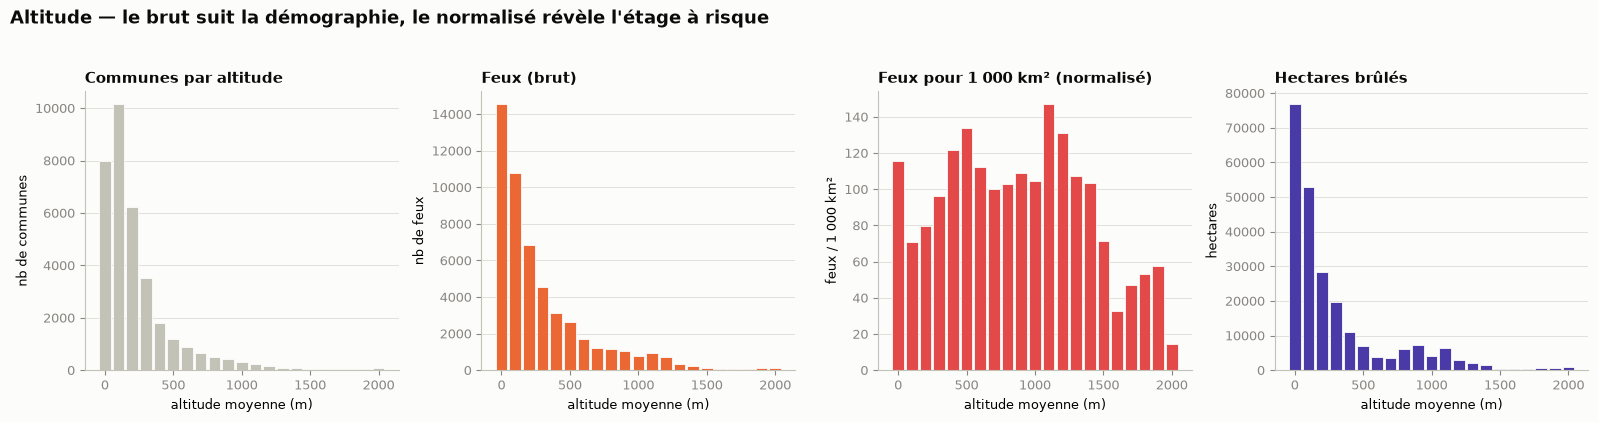

Pic de densité de feux : 1100-1200 m (147 feux / 1 000 km²)
Alors que le pic BRUT est à 0 m — là où il y a simplement le plus de communes.


In [5]:
"""FIG 5 — Altitude  ·  FIG 6 — Régions."""
A = ALT[ALT.communes >= 20].copy()          # on écarte les bandes trop peu peuplées
A["feux_par_1000km2"] = 1000 * A.feux / A.km2
A["ha_par_feu"] = A.ha / A.feux.replace(0, np.nan)

fig, ax = plt.subplots(1, 4, figsize=(16, 4.0))

ax[0].bar(A.alt_min, A.communes, width=85, color="#c3c2b7", edgecolor="#fcfcfb", linewidth=.6)
ax[0].set_title("Communes par altitude", fontsize=10.5, weight="bold", loc="left")
ax[0].set_ylabel("nb de communes")

ax[1].bar(A.alt_min, A.feux, width=85, color=ORANGE, edgecolor="#fcfcfb", linewidth=.6)
ax[1].set_title("Feux (brut)", fontsize=10.5, weight="bold", loc="left")
ax[1].set_ylabel("nb de feux")

ax[2].bar(A.alt_min, A.feux_par_1000km2, width=85, color=ROUGE,
          edgecolor="#fcfcfb", linewidth=.6)
ax[2].set_title("Feux pour 1 000 km² (normalisé)", fontsize=10.5, weight="bold", loc="left")
ax[2].set_ylabel("feux / 1 000 km²")

ax[3].bar(A.alt_min, A.ha, width=85, color=VIOLET, edgecolor="#fcfcfb", linewidth=.6)
ax[3].set_title("Hectares brûlés", fontsize=10.5, weight="bold", loc="left")
ax[3].set_ylabel("hectares")

for a in ax:
    a.set_xlabel("altitude moyenne (m)")
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
fig.suptitle("Altitude — le brut suit la démographie, le normalisé révèle l'étage à risque",
             fontsize=13, weight="bold", x=.005, ha="left", y=1.04)
plt.tight_layout(); plt.show()

pic = A.loc[A.feux_par_1000km2.idxmax()]
print(f"Pic de densité de feux : {pic.alt_min:.0f}-{pic.alt_min+100:.0f} m "
      f"({pic.feux_par_1000km2:.0f} feux / 1 000 km²)")
print(f"Alors que le pic BRUT est à {A.loc[A.feux.idxmax(), 'alt_min']:.0f} m — "
      "là où il y a simplement le plus de communes.")

## 6. Régions

Quatre classements de la même réalité. Ils ne donnent pas le même podium, et
c'est le point : « la région la plus touchée » n'a pas de sens sans préciser
*touchée comment*.

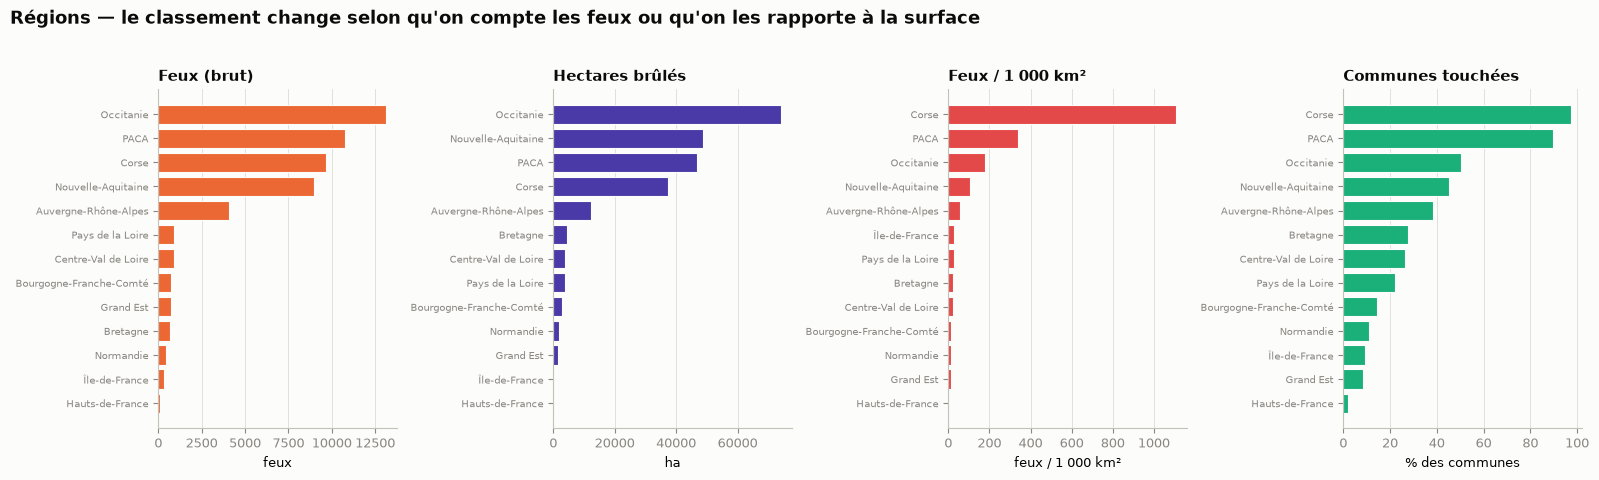

Top 3 en nombre de feux    : Occitanie, PACA, Corse
Top 3 rapporté à la surface: Corse, PACA, Occitanie
Top 3 en hectares brûlés   : Occitanie, Nouvelle-Aquitaine, PACA


In [6]:
"""FIG 6 — Régions : quatre classements de la même réalité."""
# ════════════════════════════════════════════════════════════════
# FIG 6 — Régions
# ════════════════════════════════════════════════════════════════
R = (COM.dropna(subset=["reg_nom"])
     .groupby("reg_nom")
     .agg(communes=("code_insee", "size"), feux=("nb_feux", "sum"),
          ha=("ha_brules", "sum"), km2=("superficie_km2", "sum")))
R["feux_par_1000km2"] = 1000 * R.feux / R.km2
R["ha_par_1000km2"] = 1000 * R.ha / R.km2
R["part_communes_touchees"] = (
    COM.dropna(subset=["reg_nom"]).groupby("reg_nom")
    .apply(lambda d: 100 * (d.nb_feux > 0).mean(), include_groups=False))

fig, ax = plt.subplots(1, 4, figsize=(16, 4.6))
for a, col, titre, coul, unite in [
    (ax[0], "feux", "Feux (brut)", ORANGE, "feux"),
    (ax[1], "ha", "Hectares brûlés", VIOLET, "ha"),
    (ax[2], "feux_par_1000km2", "Feux / 1 000 km²", ROUGE, "feux / 1 000 km²"),
    (ax[3], "part_communes_touchees", "Communes touchées", VERT, "% des communes"),
]:
    d = R.sort_values(col)
    a.barh(d.index, d[col], color=coul, edgecolor="#fcfcfb", linewidth=.8)
    a.set_title(titre, fontsize=10.5, weight="bold", loc="left")
    a.set_xlabel(unite)
    a.grid(axis="x", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
    a.tick_params(axis="y", labelsize=7.5)
fig.suptitle("Régions — le classement change selon qu'on compte les feux ou qu'on les rapporte à la surface",
             fontsize=13, weight="bold", x=.005, ha="left", y=1.03)
plt.tight_layout(); plt.show()

print("Top 3 en nombre de feux    :", ", ".join(R.nlargest(3, "feux").index))
print("Top 3 rapporté à la surface:", ", ".join(R.nlargest(3, "feux_par_1000km2").index))
print("Top 3 en hectares brûlés   :", ", ".join(R.nlargest(3, "ha").index))

## 7. La baseline — ce que le FWI seul prédit déjà

Avant de construire un modèle, il faut savoir ce qu'on doit battre.

Cette figure **est** la Baseline 2 du cadrage : « le Danger rating EFFIS tout
seul ». Elle donne le score de référence, et elle répond par avance à la
question de jury *« à quoi sert votre modèle, puisque le FWI existe ? »*.

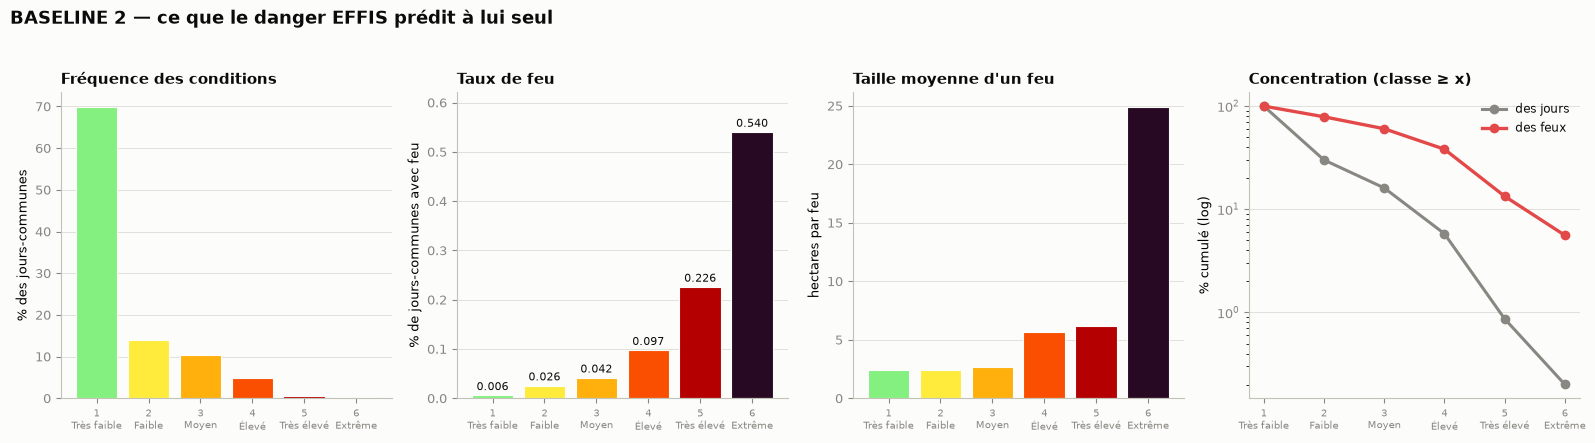

Le taux de feu passe de 0.0059 % (classe 1) à 0.5402 % (classe 6) — un gradient de ×92.
Les classes 5-6 ne représentent que 0.87 % des jours-communes mais 13 % des feux.
Un feu en classe 6 brûle 10× plus de surface qu'en classe 1.

→ C'est le score que le modèle devra battre. Le FWI seul est déjà bon :
  le gain viendra du territoire (végétation, historique), pas de la météo.


In [7]:
"""FIG 7 — La baseline EFFIS  ·  FIG 8 — saisonnalité par végétation."""
E = EFFIS.copy()
E["taux_pct"] = 100 * E.feux / E.jours_communes
E["ha_par_feu"] = E.ha / E.feux
E["part_jours"] = 100 * E.jours_communes / E.jours_communes.sum()

fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))

ax[0].bar(E.classe_effis, E.part_jours, color=COUL_EFFIS,
          edgecolor="#fcfcfb", linewidth=.8)
ax[0].set_title("Fréquence des conditions", fontsize=10.5, weight="bold", loc="left")
ax[0].set_ylabel("% des jours-communes")

ax[1].bar(E.classe_effis, E.taux_pct, color=COUL_EFFIS, edgecolor="#fcfcfb", linewidth=.8)
for c, v in zip(E.classe_effis, E.taux_pct):
    ax[1].text(c, v + E.taux_pct.max() * .02, f"{v:.3f}", ha="center", fontsize=8)
ax[1].set_title("Taux de feu", fontsize=10.5, weight="bold", loc="left")
ax[1].set_ylabel("% de jours-communes avec feu")
ax[1].set_ylim(0, E.taux_pct.max() * 1.15)

ax[2].bar(E.classe_effis, E.ha_par_feu, color=COUL_EFFIS, edgecolor="#fcfcfb", linewidth=.8)
ax[2].set_title("Taille moyenne d'un feu", fontsize=10.5, weight="bold", loc="left")
ax[2].set_ylabel("hectares par feu")

# concentration : quelle part des feux et des hectares tombe dans les classes hautes ?
cum_feux = 100 * E.feux[::-1].cumsum()[::-1] / E.feux.sum()
cum_jours = 100 * E.jours_communes[::-1].cumsum()[::-1] / E.jours_communes.sum()
ax[3].plot(E.classe_effis, cum_jours, marker="o", lw=2.2, color=MUTED, label="des jours")
ax[3].plot(E.classe_effis, cum_feux, marker="o", lw=2.4, color=ROUGE, label="des feux")
ax[3].set_yscale("log")
ax[3].set_title("Concentration (classe ≥ x)", fontsize=10.5, weight="bold", loc="left")
ax[3].set_ylabel("% cumulé (log)")
ax[3].legend(frameon=False, fontsize=8.5)

for a in ax:
    a.set_xticks(range(1, 7))
    a.set_xticklabels([f"{i}\n{n}" for i, n in zip(range(1, 7), NOM_EFFIS)], fontsize=7)
    a.set_xlabel("")
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
fig.suptitle("BASELINE 2 — ce que le danger EFFIS prédit à lui seul",
             fontsize=13, weight="bold", x=.005, ha="left", y=1.04)
plt.tight_layout(); plt.show()

grad = E.taux_pct.iloc[-1] / E.taux_pct.iloc[0]
p_j = E[E.classe_effis >= 5].jours_communes.sum() / E.jours_communes.sum() * 100
p_f = E[E.classe_effis >= 5].feux.sum() / E.feux.sum() * 100
print(f"Le taux de feu passe de {E.taux_pct.iloc[0]:.4f} % (classe 1) à "
      f"{E.taux_pct.iloc[-1]:.4f} % (classe 6) — un gradient de ×{grad:.0f}.")
print(f"Les classes 5-6 ne représentent que {p_j:.2f} % des jours-communes "
      f"mais {p_f:.0f} % des feux.")
print(f"Un feu en classe 6 brûle {E.ha_par_feu.iloc[-1] / E.ha_par_feu.iloc[0]:.0f}× "
      "plus de surface qu'en classe 1.")
print("\n→ C'est le score que le modèle devra battre. Le FWI seul est déjà bon :")
print("  le gain viendra du territoire (végétation, historique), pas de la météo.")

## 8. Deux saisons de feu

L'audit BDIFF avait révélé un **second pic en mars**, non anticipé par le
cadrage. Hypothèse à tester : c'est l'écobuage agricole, donc il devrait
apparaître sur les communes agricoles et pas sur le maquis.

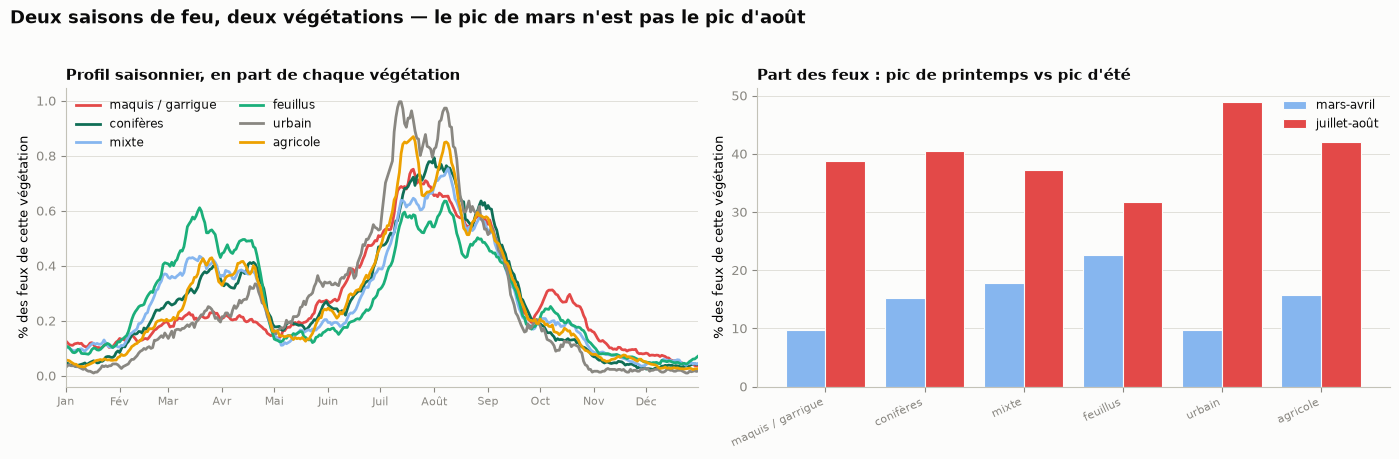

Part des feux tombant en mars-avril :
   feuillus              22.6 %   (juillet-août :  31.8 %)
   mixte                 17.9 %   (juillet-août :  37.2 %)
   agricole              15.8 %   (juillet-août :  42.0 %)
   conifères             15.2 %   (juillet-août :  40.5 %)
   urbain                 9.7 %   (juillet-août :  48.8 %)
   maquis / garrigue      9.7 %   (juillet-août :  38.7 %)

Il y a bien DEUX saisons de feu distinctes, et elles ne concernent pas
les mêmes territoires :
   • le maquis est un feu d'ÉTÉ presque pur (10 % au printemps seulement)
   • les feuillus portent le pic de PRINTEMPS (23 %, le plus élevé)

⚠️  L'hypothèse de départ — « le pic de mars est l'écobuage agricole » —
    n'est PAS confirmée : l'agricole n'est qu'à 16 %, derrière les feuillus.
    Le pic de printemps concerne surtout les forêts de feuillus (Pyrénées,
    Massif central), où l'écobuage se pratique en zone de montagne boisée.

→ Conséquence pour le modèle : un seul terme saisonnier ne suffira p

In [8]:
"""FIG 8 — la saisonnalité selon la végétation."""
# ════════════════════════════════════════════════════════════════
# FIG 8 — la saisonnalité selon la végétation
# ════════════════════════════════════════════════════════════════
S = SAISON[SAISON.doy <= 365].copy()
piv_s = S.pivot_table(index="doy", columns="vegetation", values="feux",
                      aggfunc="sum").reindex(range(1, 366)).fillna(0)
piv_s = piv_s.rolling(11, center=True, min_periods=1).mean()
# en PART de chaque végétation : sinon on ne voit que les volumes
part = piv_s / piv_s.sum() * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
for v in [c for c in ORDRE_VEG if c in part.columns]:
    ax[0].plot(part.index, part[v], lw=2, color=COUL_VEG[v], label=v)
ax[0].set_title("Profil saisonnier, en part de chaque végétation",
                fontsize=11, weight="bold", loc="left")
ax[0].set_ylabel("% des feux de cette végétation")
ax[0].legend(frameon=False, fontsize=8.5, ncol=2)

# zoom sur le pic de mars : est-il agricole ?
mars = part.loc[60:105].sum()
ete = part.loc[182:243].sum()
cmp = pd.DataFrame({"mars-avril": mars, "juillet-août": ete}).reindex(
    [v for v in ORDRE_VEG if v in part.columns])
x = np.arange(len(cmp))
ax[1].bar(x - .2, cmp["mars-avril"], .4, color="#86b6ef",
          edgecolor="#fcfcfb", linewidth=.8, label="mars-avril")
ax[1].bar(x + .2, cmp["juillet-août"], .4, color=ROUGE,
          edgecolor="#fcfcfb", linewidth=.8, label="juillet-août")
ax[1].set_xticks(x); ax[1].set_xticklabels(cmp.index, rotation=25, ha="right", fontsize=8)
ax[1].set_title("Part des feux : pic de printemps vs pic d'été",
                fontsize=11, weight="bold", loc="left")
ax[1].set_ylabel("% des feux de cette végétation")
ax[1].legend(frameon=False, fontsize=8.5)

for a in ax:
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
ax[0].set_xticks(DEB_MOIS); ax[0].set_xticklabels(MOIS, fontsize=8)
ax[0].set_xlim(1, 365)
fig.suptitle("Deux saisons de feu, deux végétations — le pic de mars n'est pas le pic d'août",
             fontsize=13, weight="bold", x=.005, ha="left", y=1.03)
plt.tight_layout(); plt.show()

print("Part des feux tombant en mars-avril :")
for v in cmp.sort_values("mars-avril", ascending=False).index:
    print(f"   {v:20s} {cmp.loc[v,'mars-avril']:5.1f} %   "
          f"(juillet-août : {cmp.loc[v,'juillet-août']:5.1f} %)")
print()
print("Il y a bien DEUX saisons de feu distinctes, et elles ne concernent pas")
print("les mêmes territoires :")
print(f"   • le maquis est un feu d'ÉTÉ presque pur "
      f"({cmp.loc['maquis / garrigue','mars-avril']:.0f} % au printemps seulement)")
print(f"   • les feuillus portent le pic de PRINTEMPS "
      f"({cmp.loc['feuillus','mars-avril']:.0f} %, le plus élevé)")
print()
print("⚠️  L'hypothèse de départ — « le pic de mars est l'écobuage agricole » —")
print(f"    n'est PAS confirmée : l'agricole n'est qu'à "
      f"{cmp.loc['agricole','mars-avril']:.0f} %, derrière les feuillus.")
print("    Le pic de printemps concerne surtout les forêts de feuillus (Pyrénées,")
print("    Massif central), où l'écobuage se pratique en zone de montagne boisée.")
print()
print("→ Conséquence pour le modèle : un seul terme saisonnier ne suffira pas.")
print("  L'interaction végétation × saison porte une information réelle.")

## 9. Synthèse

### Ce que le croisement établit

| Constat | Chiffre |
|---|---|
| Le FWI seul discrimine très bien | taux de feu ×92 entre classe 1 et classe 6 |
| Les conditions extrêmes sont rares mais décisives | 0,87 % des jours-communes → 13 % des feux |
| Un feu en danger extrême est bien plus grand | ×10 en surface moyenne |
| **Mais la végétation ajoute autant** | à météo ÉGALE, maquis vs agricole : **×6 à ×60** |
| Le maquis concentre le risque | 26× plus de feux par km² que l'agricole |
| L'allumage suit les humains | à combustible égal, 15× plus en ville qu'en rural dispersé |
| Le classement régional dépend de la mesure | Occitanie en volume, Corse rapporté à la surface |
| Deux saisons distinctes | maquis = été ; feuillus = printemps |

### Ce que ça implique pour la modélisation

1. **Le modèle a une raison d'exister.** Le FWI porte le *quand*, le territoire
   porte le *où* — et l'écart à météo constante prouve que le second n'est pas
   redondant avec le premier.
2. **L'interaction végétation × météo est réelle**, et elle n'est pas linéaire :
   l'écart maquis/agricole passe de ×60 en conditions calmes à ×6 en conditions
   extrêmes. Quand le danger est maximal, tout brûle ; c'est en conditions
   moyennes que le territoire fait la différence. Les modèles à base d'arbres
   capteront cela nativement.
3. **Un seul terme saisonnier ne suffira pas** — les deux pics ne concernent
   pas les mêmes végétations.
4. **La baseline est exigeante.** Le FWI seul est déjà un bon prédicteur : le
   gain devra venir des features territoriales, pas d'un réglage d'algorithme.

### Deux hypothèses de départ que les données ont réfutées

- **La relation en cloche avec la densité de population** n'existe pas : la
  relation est monotone, l'allumage humain domine largement l'effet
  « moins de végétation en ville ».
- **Le pic de mars n'est pas principalement agricole** : ce sont les forêts de
  **feuillus** qui le portent (22,6 % de leurs feux au printemps, contre
  15,8 % pour l'agricole).

### Limites

- La végétation dominante est figée au **millésime CORINE 2018** dans ces
  agrégats ; la matrice d'entraînement, elle, apparie correctement le millésime
  le plus récent antérieur à chaque date.
- Les seuils de classification (`part_maquis > 0.15`, etc.) sont **arbitraires**.
  Ils servent à rendre l'analyse lisible, pas à alimenter le modèle — qui reçoit
  les parts continues.
- ~31 communes partagent la même maille météo de 28 km : les classes EFFIS ne
  différencient pas deux communes voisines.